In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

nama_file = list(uploaded.keys())[0]
df = pd.read_csv(nama_file)

print("Nama file:", nama_file)
print("Ukuran dataset:", df.shape)

df.head()

Saving furniture_10k_FINAL.csv to furniture_10k_FINAL (1).csv
Nama file: furniture_10k_FINAL (1).csv
Ukuran dataset: (10000, 13)


,sales_date,order_id,customer_name,product_name,category,price,quantity,discount,total,shipping_fee,total_sales,status,shipping_address
0,2025-07-31,ORD00001,Customer_332,Kitchen Set,Dapur,9500000,1,0.0,9500000,60000,9560000,cancelled,"Kelurahan 120, Jakarta Pusat"
1,2025-11-03,ORD00002,Customer_1150,Nakas,Kamar Tidur,1000000,2,0.0,2000000,60000,2060000,completed,"Kelurahan 9, Jakarta Pusat"
2,2025-10-31,ORD00003,Customer_2122,Kursi Bar,Ruang Makan,1295000,2,0.0,2590000,60000,2650000,completed,"Kelurahan 108, Jakarta Pusat"
3,2025-06-19,ORD00004,Customer_2636,Kasur,Kamar Tidur,5500000,3,0.0,16500000,50000,16550000,completed,"Kelurahan 36, Bogor"
4,2025-06-19,ORD00005,Customer_3379,Meja Makan,Ruang Makan,3200000,3,0.0,9600000,60000,9660000,completed,"Kelurahan 73, Tangerang"


In [ ]:
# Cek data duplikat
jumlah_duplikat = df.duplicated().sum()
print("Jumlah duplikat sebelum dibersihkan:",
      jumlah_duplikat)

# Hapus data duplikat
df = df.drop_duplicates()

print("Jumlah duplikat setelah dibersihkan:",
      df.duplicated().sum())

print("Jumlah baris setelah dibersihkan:",
      len(df))

Jumlah duplikat sebelum dibersihkan: 0
Jumlah duplikat setelah dibersihkan: 0
Jumlah baris setelah dibersihkan: 10000


In [ ]:
# Cek missing value
missing_sebelum = df['shipping_address'].isna().sum()
print("Missing value sebelum diisi:",
      missing_sebelum)

# Isi data kosong dengan Unknown
df['shipping_address'] = (
    df['shipping_address'].fillna('Unknown')
)

print("Missing value setelah diisi:",
      df['shipping_address'].isna().sum())

Missing value sebelum diisi: 0
Missing value setelah diisi: 0


In [ ]:
# Cek tipe data tanggal
print("Tipe data sebelum:",
      df['sales_date'].dtype)

# Ubah sales_date menjadi datetime
df['sales_date'] = pd.to_datetime(
    df['sales_date']
)

print("Tipe data setelah:",
      df['sales_date'].dtype)

Tipe data sebelum: object
Tipe data setelah: datetime64[ns]


In [ ]:
# Cek informasi akhir dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sales_date        10000 non-null  datetime64[ns]
 1   order_id          10000 non-null  object        
 2   customer_name     10000 non-null  object        
 3   product_name      10000 non-null  object        
 4   category          10000 non-null  object        
 5   price             10000 non-null  int64         
 6   quantity          10000 non-null  int64         
 7   discount          10000 non-null  float64       
 8   total             10000 non-null  int64         
 9   shipping_fee      10000 non-null  int64         
 10  total_sales       10000 non-null  int64         
 11  status            10000 non-null  object        
 12  shipping_address  10000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(6)
memory usage: 1015.8+ K

In [ ]:
# Ambil nama kota dari alamat
df['city'] = (
    df['shipping_address']
    .str.split(',')
    .str[-1]
    .str.strip()
)

# Tampilkan hasilnya
df[['shipping_address', 'city']].head()

,shipping_address,city
0,"Kelurahan 120, Jakarta Pusat",Jakarta Pusat
1,"Kelurahan 9, Jakarta Pusat",Jakarta Pusat
2,"Kelurahan 108, Jakarta Pusat",Jakarta Pusat
3,"Kelurahan 36, Bogor",Bogor
4,"Kelurahan 73, Tangerang",Tangerang


In [ ]:
# Ambil pesanan yang completed
df_completed = df[
    df['status'].str.strip().str.lower() == 'completed'
].copy()

print("Jumlah pesanan completed:", len(df_completed))

df_completed[
    ['order_id', 'status', 'city', 'total_sales']
].head()

Jumlah pesanan completed: 8972


,order_id,status,city,total_sales
1,ORD00002,completed,Jakarta Pusat,2060000
2,ORD00003,completed,Jakarta Pusat,2650000
3,ORD00004,completed,Bogor,16550000
4,ORD00005,completed,Tangerang,9660000
5,ORD00006,completed,Tangerang,1910000


In [ ]:
# Hitung total penjualan per kota
sales_by_city = (
    df_completed
    .groupby('city', as_index=False)['total_sales']
    .sum()
    .sort_values('total_sales', ascending=False)
    .reset_index(drop=True)
)

sales_by_city

,city,total_sales
0,Jakarta Utara,5068862000
1,Jakarta Barat,5021356500
2,Jakarta Pusat,4996988000
3,Depok,4854175000
4,Bogor,4811721500
5,Jakarta Selatan,4764095500
6,Jakarta Timur,4666865000
7,Tangerang Selatan,4544961500
8,Tangerang,4415711500
9,Bekasi,4335769500


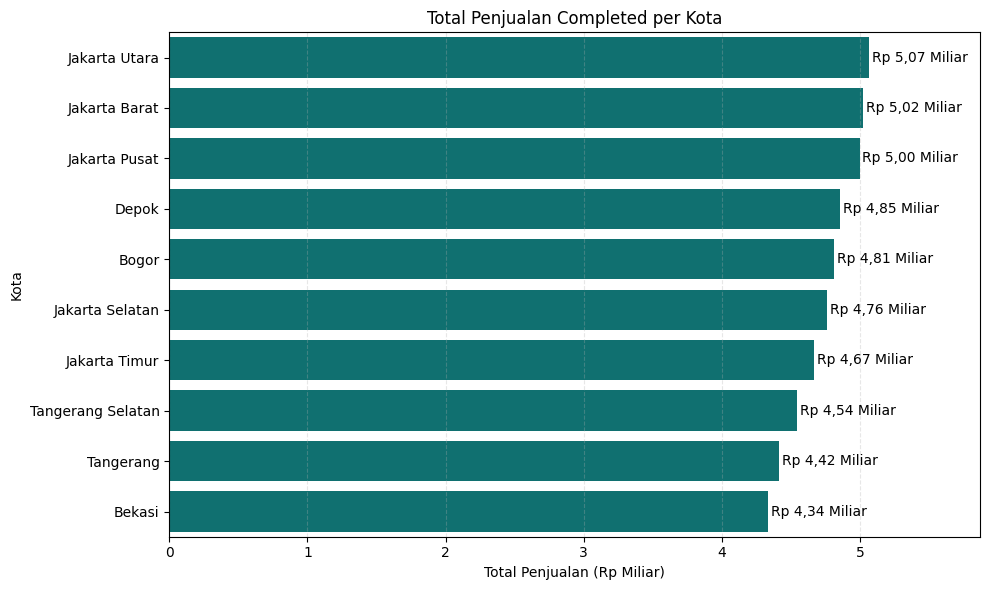

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Urutkan omzet dari terbesar ke terkecil
plot_city = sales_by_city.sort_values(
    'total_sales',
    ascending=False
).copy()

# Ubah nilai omzet menjadi miliar
plot_city['total_miliar'] = (
    plot_city['total_sales'] / 1_000_000_000
)

# Buat bar chart horizontal dengan Seaborn
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_city,
    x='total_miliar',
    y='city',
    order=plot_city['city'],
    color='teal'
)

ax.set_title('Total Penjualan Completed per Kota')
ax.set_xlabel('Total Penjualan (Rp Miliar)')
ax.set_ylabel('Kota')

# Sentuhan akhir: label rupiah di ujung batang
for bar in ax.patches:
    nilai = bar.get_width()
    label = f'Rp {nilai:.2f} Miliar'.replace('.', ',')

    ax.text(
        nilai + 0.02,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center'
    )

ax.set_xlim(0, plot_city['total_miliar'].max() + 0.8)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Ambil pesanan completed yang menggunakan diskon
df_promo = df[
    (df['status'].str.strip().str.lower() == 'completed') &
    (df['discount'] > 0)
].copy()

print("Jumlah pesanan completed dengan diskon:",
      len(df_promo))

df_promo[
    ['order_id', 'product_name', 'discount',
     'quantity', 'total_sales']
].head()

Jumlah pesanan completed dengan diskon: 293


,order_id,product_name,discount,quantity,total_sales
9,ORD00010,Lemari TV,0.1,1,2120000
27,ORD00028,Rak Sepatu,0.1,2,1230000
35,ORD00036,Lemari Baju,0.1,2,6360000
42,ORD00043,Lemari Sliding,0.1,3,12885000
44,ORD00045,Lemari Laci,0.1,3,5325000


In [ ]:
# Agregasi transaksi promosi berdasarkan produk
agregasi_produk = (
    df_promo
    .groupby('product_name', as_index=False)
    .agg(
        total_omzet=('total_sales', 'sum'),
        rata_rata_diskon=('discount', 'mean'),
        rata_rata_kuantitas=('quantity', 'mean')
    )
    .sort_values('total_omzet', ascending=False)
    .reset_index(drop=True)
)

# Ubah diskon menjadi persen dan bulatkan hasil rata-rata
agregasi_produk['rata_rata_diskon'] = (
    agregasi_produk['rata_rata_diskon'] * 100
).round(2)

agregasi_produk['rata_rata_kuantitas'] = (
    agregasi_produk['rata_rata_kuantitas'].round(2)
)

# Tampilkan hasil agregasi
agregasi_produk

,product_name,total_omzet,rata_rata_diskon,rata_rata_kuantitas
0,Kitchen Set,214530000,10.0,1.79
1,Kasur,139400000,10.0,2.00
2,Lemari Baju,114480000,10.0,1.89
3,Lemari Sliding,107435000,10.0,2.50
4,Bufet,106270000,10.0,2.12
5,Sofa,101870000,10.0,2.27
6,Lemari TV,79670000,10.0,2.11
7,Lemari Dapur,67880000,10.0,1.74
8,Lemari Sudut,62615000,10.0,1.92
9,Meja Rias,56125000,10.0,1.94


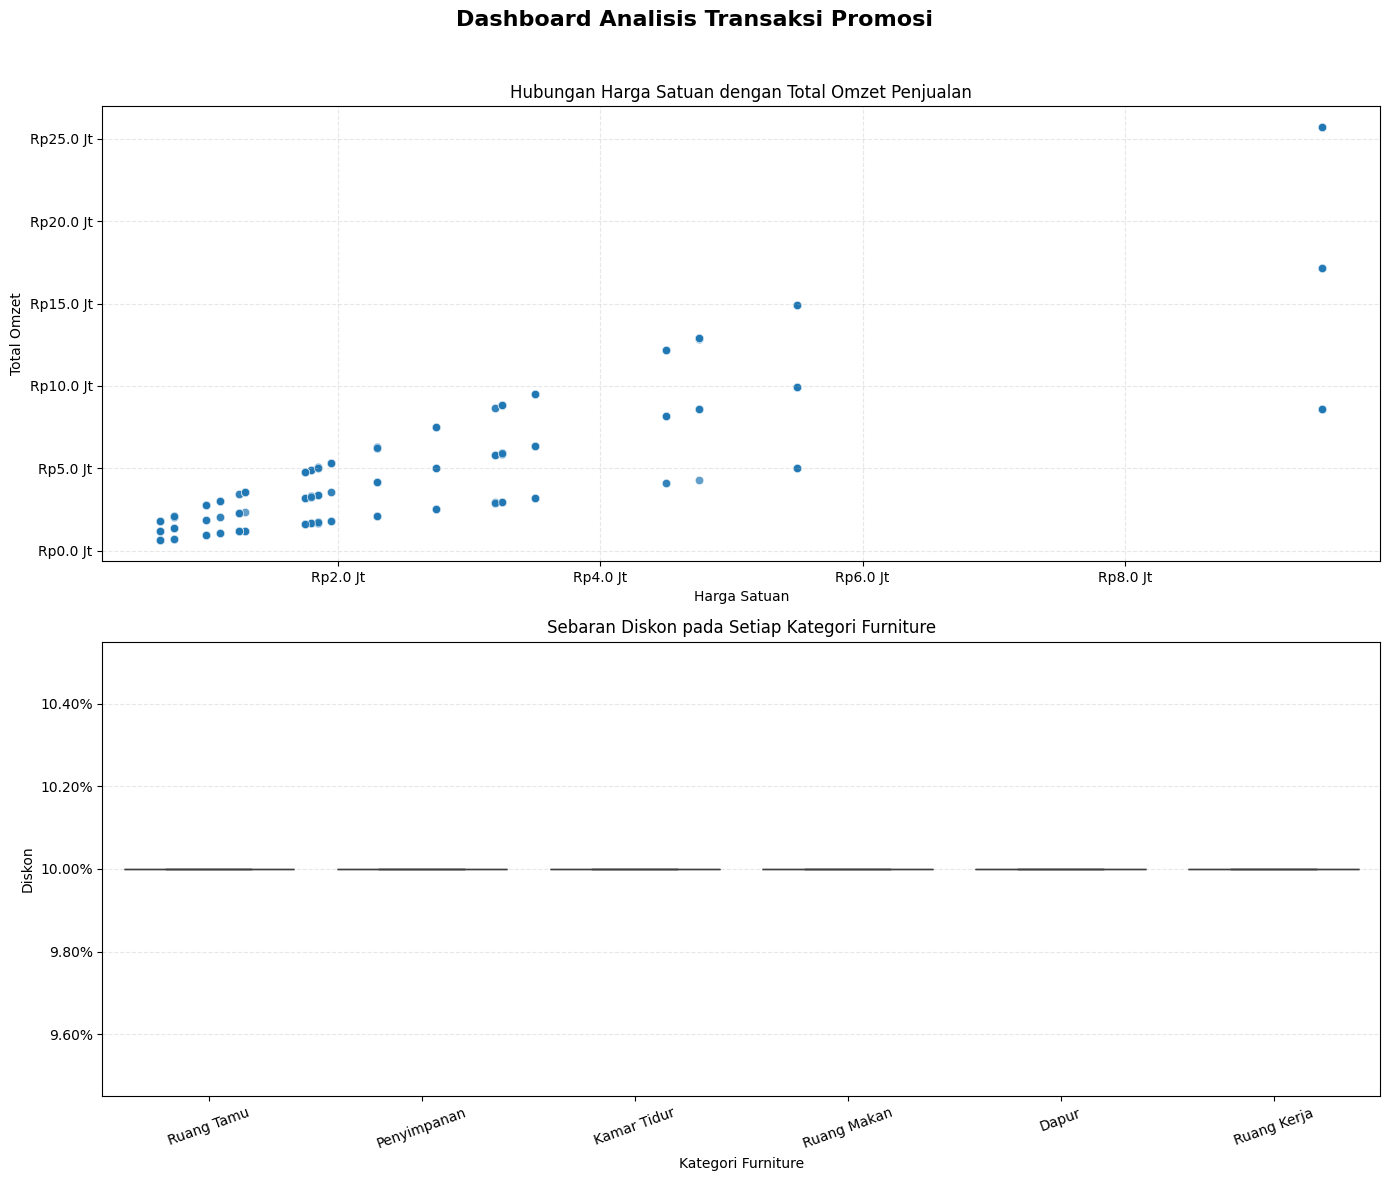

In [ ]:
# Membuat dashboard subplot 2 baris dan 1 kolom
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Scatter plot harga satuan dan total omzet
sns.scatterplot(
    data=df_promo,
    x='price',
    y='total_sales',
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title('Hubungan Harga Satuan dengan Total Omzet Penjualan')
axes[0].set_xlabel('Harga Satuan')
axes[0].set_ylabel('Total Omzet')
axes[0].grid(axis='both', linestyle='--', alpha=0.3)

# Format angka menjadi rupiah dalam juta
format_rupiah = FuncFormatter(
    lambda nilai, posisi: f'Rp{nilai / 1_000_000:.1f} Jt'
)

axes[0].xaxis.set_major_formatter(format_rupiah)
axes[0].yaxis.set_major_formatter(format_rupiah)

# Plot 2: Box plot diskon berdasarkan kategori
sns.boxplot(
    data=df_promo,
    x='category',
    y='discount',
    ax=axes[1]
)

axes[1].set_title('Sebaran Diskon pada Setiap Kategori Furniture')
axes[1].set_xlabel('Kategori Furniture')
axes[1].set_ylabel('Diskon')
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

# Judul utama dan pengaturan tampilan
fig.suptitle(
    'Dashboard Analisis Transaksi Promosi',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()